In [2]:
import math
import numpy
import camera_setup as cs
import json
import random
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
robot_coords = []
cam_coords = []
files = ["robo_coords.txt", "saved_coordinates.txt"]

for i in files:
    with open(i, "r") as f:
        if i == "robo_coords.txt":
            lines = f.readlines()
            for i in lines:
                x = json.loads(i)
                robot_coords.append(x)
        
        else:
            lines = f.readlines()
            for i in lines:
                x = json.loads(i)
                cam_coords.append(x)

print(robot_coords)
print(cam_coords)

[[551.255, 30.4549, -44.9023], [515.537, -196.268, -43.1387], [273.764, -196.429, -39.5692], [523.496, 174.052, -45.0883], [380.401, -209.621, -36.971], [203.086, -223.181, -38.7565], [509.772, 36.445, -50.9596], [276.305, -21.3069, -38.6157], [400.672, 212.686, -40.2759], [406.959, -231.356, -38.1634], [470.043, 207.363, -45.4265], [304.793, 305.003, -41.4565], [385.001, -12.2891, -54.6942], [205.262, 3.93179, -57.6336], [416.311, -213.356, -48.4041], [534.322, -5.74047, -41.57], [426.716, 229.902, -37.3286], [204.95, 345.379, -77.5168], [542.387, -39.571, -44.1623], [520.879, 328.839, -37.6339], [440.33, -207.238, -42.5005], [231.206, -201.455, -39.1405], [391.508, 234.471, -37.3575], [155.306, 38.3378, -85.9361], [169.847, 318.745, -85.2682], [277.234, -126.764, -53.354], [409.887, 201.838, -43.3455], [274.899, 96.9987, -38.3193], [548.39, -89.0096, -47.9837], [394.163, 360.014, -45.2465], [598.309, 95.9621, -44.5715], [447.773, -180.738, -46.3767], [318.486, 198.147, -37.1672], [28

In [ ]:
count = 3
standard_deviation_list = []
mean_value_list = []
best_rms_list = []
worst_rms_list = []
best_rms_comb_list = []

while count <= len(robot_coords)-1:
    robot_combinations = []
    cam_combinations = []
    index_list = []
    rms_error_list = []
    
    best_rms = math.inf
    worst_rms = 0
    i = 0
    while i < 5000:
        dummy_robot_list = []
        dummy_cam_list = []
        element_list = []
        while len(element_list) <= count -1:
            rand_index = random.randint(0,len(robot_coords)-1)
            if rand_index not in element_list:
                element_list.append(rand_index)
        if element_list not in index_list:
            index_list.append(element_list)
            for element in element_list:
                dummy_robot_list.append(robot_coords[element])
                dummy_cam_list.append(cam_coords[element])
            cam_combinations.append(dummy_cam_list)
            robot_combinations.append(dummy_robot_list)
            i += 1
    #print(robot_combinations)
    for i in range(len(cam_combinations)):
        rot,trans =cs.estimate_rigid_transform(cam_combinations[i], robot_combinations[i])
        rms_error = cs.rms_alignment_error(cam_combinations[i], robot_combinations[i], rot, trans)
        rms_error_list.append(rms_error)
        if rms_error < best_rms:
            best_rms = rms_error
            best_rms_index = i
        if rms_error > worst_rms:
            worst_rms = rms_error
            worst_rms_index = i 
    mean_value = numpy.mean(rms_error_list)
    standard_deviation = numpy.std(rms_error_list)
    mean_value_list.append(mean_value)
    standard_deviation_list.append(standard_deviation)
    best_rms_list.append(best_rms)
    worst_rms_list.append(worst_rms)
    best_rms_comb_list.append(index_list[best_rms_index])
    print(f"Num_positions:{count}\n Worst RMS:{worst_rms}\n Worst RMS Index:{worst_rms_index}\n Mean RMS: {mean_value}\n Std Deviation: {standard_deviation}\n Worst RMS combination {index_list[worst_rms_index]}\n")
    count += 1
for i in range(len(best_rms_comb_list)):
    print(f"Best RMS combination for {i+3} Positions: {best_rms_comb_list[i]}")
    
    

Num_positions:3
 Worst RMS:28.337796909717017
 Worst RMS Index:1992
 Mean RMS: 11.884455223331187
 Std Deviation: 4.874515991279907
 Worst RMS combination [51, 69, 54]

Num_positions:4
 Worst RMS:28.130044932732847
 Worst RMS Index:3011
 Mean RMS: 14.146769767301818
 Std Deviation: 4.168796355307928
 Worst RMS combination [30, 69, 2, 51]

Num_positions:5
 Worst RMS:27.176973211438284
 Worst RMS Index:744
 Mean RMS: 15.40875382945994
 Std Deviation: 3.5263727386673236
 Worst RMS combination [51, 64, 2, 69, 36]

Num_positions:6
 Worst RMS:28.655738340394937
 Worst RMS Index:2667
 Mean RMS: 16.165018994451138
 Std Deviation: 3.1721558742875997
 Worst RMS combination [54, 40, 44, 69, 73, 2]

Num_positions:7
 Worst RMS:26.910300779513925
 Worst RMS Index:4743
 Mean RMS: 16.73639950886922
 Std Deviation: 2.8581174307031065
 Worst RMS combination [26, 2, 69, 1, 64, 52, 75]

Num_positions:8
 Worst RMS:25.221955853304628
 Worst RMS Index:1674
 Mean RMS: 17.127512339664833
 Std Deviation: 2.5882

: 

In [16]:
print(best_rms_list)
print(worst_rms_list)
print(standard_deviation_list)
print(mean_value_list)

[0.4974614455596668, 2.754781814788134, 4.781330108313724, 6.039574984530299, 7.462371043845263, 7.951656912344337, 7.56545308532553, 9.116736536819426, 10.472599064188843, 11.092743624639372, 11.938019460823218, 11.638724749307624, 12.883140811676924, 12.596451831344918, 13.22066049839683, 13.209946283694812, 13.58573533713531, 13.534005712510845, 12.904623523055525, 13.906384447547104, 14.227470406314099, 14.12800254184911, 14.50051689474534, 14.493260995488638, 14.926642052191173, 15.144571710770874, 14.949390281804282, 15.777535767154836, 15.697775246242646, 15.406311907453711, 15.55576599441614, 15.473135686611498, 15.925326170112863, 16.184164511461532, 15.230539648045331, 16.161972386872932, 16.61081358910729, 16.196841252923893, 16.446890488227066, 16.081192617165517, 16.798232559414387, 16.758992832304557, 16.796431513916854, 16.89509427771558, 16.780200480048475, 17.14508622483078, 17.00488909841875, 16.570776780287478, 17.32990035358708, 17.166976650511558, 17.42701202225734

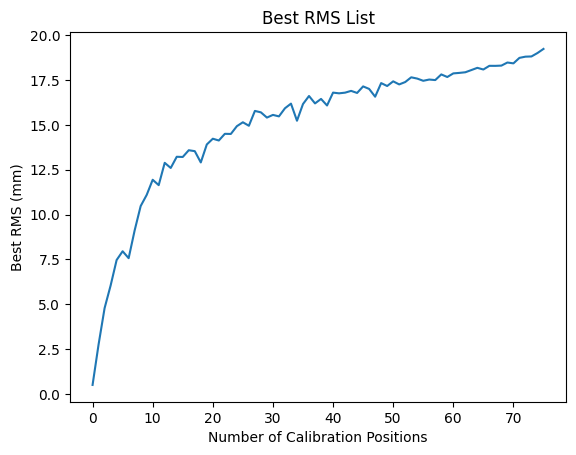

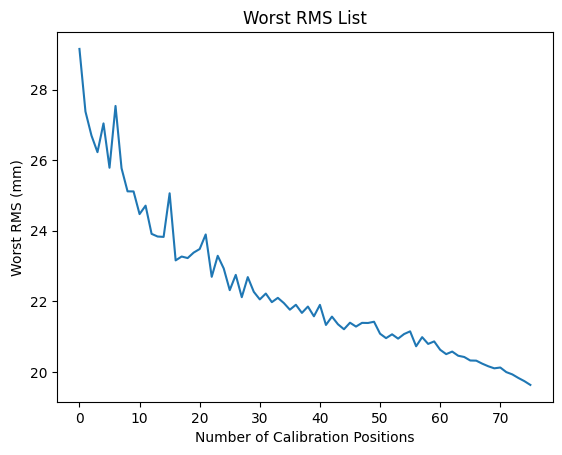

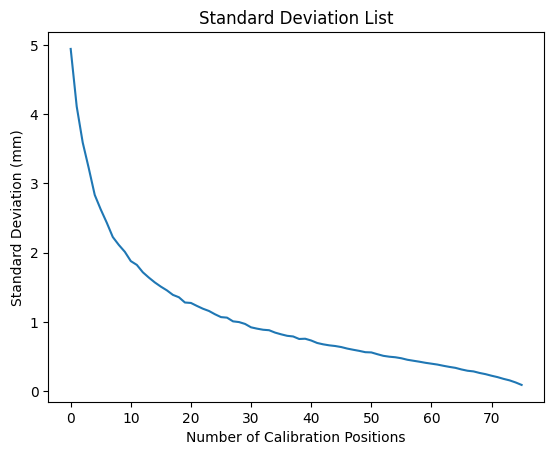

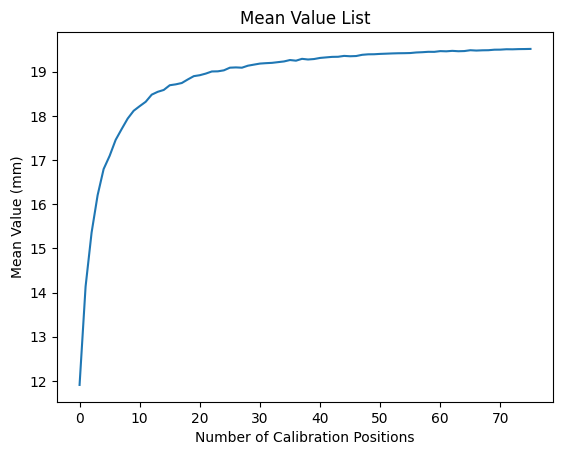

In [17]:
# ---- Plot 1: Best RMS ----
plt.figure()
plt.plot(best_rms_list)
plt.title("Best RMS List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Best RMS (mm)")
plt.show()

# ---- Plot 2: Worst RMS ----
plt.figure()
plt.plot(worst_rms_list)
plt.title("Worst RMS List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Worst RMS (mm)")
plt.show()

# ---- Plot 3: Standard Deviation ----
plt.figure()
plt.plot(standard_deviation_list)
plt.title("Standard Deviation List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Standard Deviation (mm)")
plt.show()

# ---- Plot 4: Mean Value ----
plt.figure()
plt.plot(mean_value_list)
plt.title("Mean Value List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Mean Value (mm)")
plt.show()